بسم الله

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from tabulate import tabulate

# إعدادات العرض
sns.set(style='whitegrid', palette='muted', color_codes=True)

# النمذجة التنبؤية
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# تثبيت العشوائية
import random
random.seed(42)
np.random.seed(42)

# مكتبة الإحصاء والتحذيرات
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
# محاولة القراءة بترميز مختلف

In [8]:
df = pd.read_csv("D:\AI Delta University\Level 4\Semester 1\Graduation Project\Project\Baytology\Datasets\egypt_real_estate_listings.csv")
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


In [9]:
df.tail()


,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
19919,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,500,000",Code: 2404\nChalet for sale in North Edge Towe...,"North Edge Towers, New Alamein City, Al Alamei...",Chalet,"1,259 sqft / 117 sqm",2,2,21 Aug 2025,Cash,NaN
19920,https://www.propertyfinder.eg/en/plp/buy/duple...,"24,000,000",Duplex for sale in Eastown -Sodic\n5th settlem...,"Eastown, 5th Settlement Compounds, The 5th Set...",Duplex,"2,756 sqft / 256 sqm",3+ Maid,4,1 Sep 2025,Cash,NaN
19921,https://www.propertyfinder.eg/en/plp/buy/chale...,"3,000,000",Chalet for Sale in One of the Prime Projects o...,"White Sand, Markaz Al Hamam, North Coast",Chalet,"1,195 sqft / 111 sqm",2,2,30 Jul 2025,Cash,NaN
19922,https://www.propertyfinder.eg/en/plp/buy/villa...,"9,500,000",Villa for sale in installments in Sarai Compou...,"Sarai, Mostakbal City Compounds, Mostakbal Cit...",Villa,"2,573 sqft / 239 sqm",5,4,23 Aug 2025,Cash,NaN
19923,https://www.propertyfinder.eg/en/plp/buy/chale...,"7,500,000",Ground Chalet with Garden in Mountain View Nor...,"Mountain View, Qesm Ad Dabaah, North Coast",Chalet,990 sqft / 92 sqm,2,2,21 Aug 2025,Cash,NaN


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [11]:
df.dtypes


url               object
price             object
description       object
location          object
type              object
size              object
bedrooms          object
bathrooms         object
available_from    object
payment_method    object
down_payment      object
dtype: object

In [6]:
df.describe()


,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,16,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1 Sep 2025,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6562,3254,15521,203


In [12]:
df.isnull().sum()


url                   0
price               539
description          78
location             91
type                 77
size                 77
bedrooms            144
bathrooms           140
available_from      663
payment_method      541
down_payment      14479
dtype: int64

<Axes: >

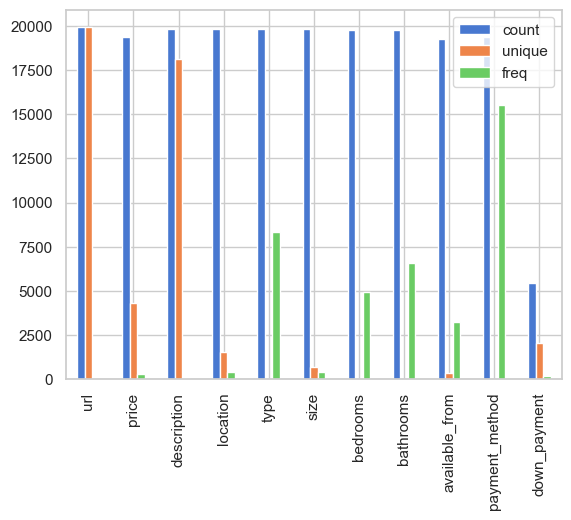

In [13]:
df.describe().T.plot(kind='bar')


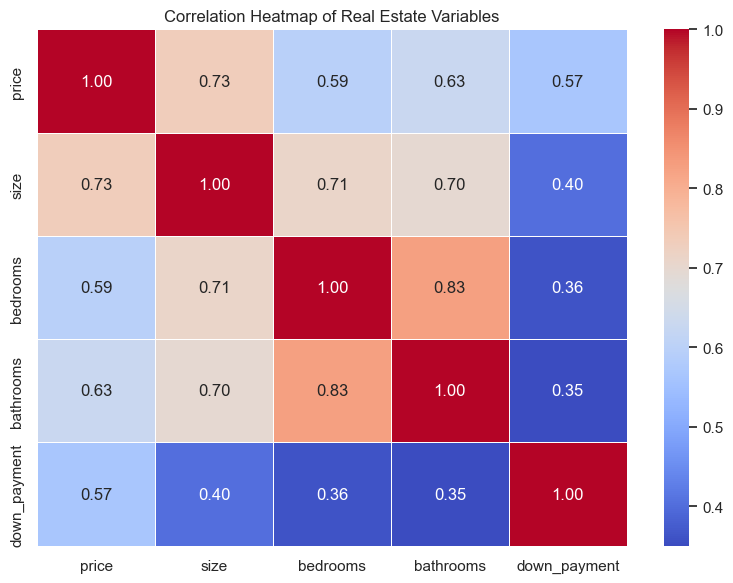

In [14]:
# Convert selected columns to numeric
numeric_columns = ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# Drop rows with missing values
df_corr = df[numeric_columns].dropna()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Real Estate Variables')
plt.tight_layout()
plt.show()


In [15]:
# for col in df:
#     if df[col].dtype == 'O':
#         sns.countplot(x=col,data=df)
#         plt.show()

KeyboardInterrupt: 

In [16]:
df.dtypes


url                object
price             float64
description        object
location           object
type               object
size              float64
bedrooms          float64
bathrooms         float64
available_from     object
payment_method     object
down_payment      float64
dtype: object

In [17]:
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,8000000.0,OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732.0,1.0,1.0,31 Aug 2025,Cash,1200000.0
1,https://www.propertyfinder.eg/en/plp/buy/villa...,25000000.0,"For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,2368.0,4.0,4.0,2 Sep 2025,Cash,2100000.0
2,https://www.propertyfinder.eg/en/plp/buy/chale...,15135000.0,"With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,1270.0,2.0,2.0,19 Aug 2025,Cash,1513000.0
3,https://www.propertyfinder.eg/en/plp/buy/apart...,12652000.0,Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,1787.0,3.0,2.0,26 Aug 2025,Installments,1260000.0
4,https://www.propertyfinder.eg/en/plp/buy/villa...,45250000.0,Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,4306.0,7.0,7.0,2 Sep 2025,Cash,2262500.0


In [18]:
# Create label encoders for categorical columns
label_encoders = {}
categorical_columns = ['location', 'type', 'payment_method']

# Create new DataFrame with encoded values
df_encoded = df.copy()

# Encode categorical columns
for col in categorical_columns:
    label_encoders[col] = LabelEncoder()
    # Fill NaN values with a placeholder before encoding
    df_encoded[col] = df_encoded[col].fillna('Unknown')
    df_encoded[col] = label_encoders[col].fit_transform(df_encoded[col])

# Convert available_from to numerical values (days from today)
df_encoded['available_from'] = pd.to_datetime(df_encoded['available_from'], format='%d %b %Y', errors='coerce')
df_encoded['days_until_available'] = (df_encoded['available_from'] - pd.Timestamp.now()).dt.days

# Drop original available_from column and any remaining null values
df_encoded.drop(['available_from', 'url', 'description'], axis=1, inplace=True)
df_encoded = df_encoded.dropna()

# Display the first few rows of the encoded dataset
print("Shape of encoded dataset:", df_encoded.shape)
df_encoded.head()

Shape of encoded dataset: (5111, 9)


,price,location,type,size,bedrooms,bathrooms,payment_method,down_payment,days_until_available
0,8000000.0,1346,4,732.0,1.0,1.0,0,1200000.0,-69.0
1,25000000.0,785,15,2368.0,4.0,4.0,0,2100000.0,-67.0
2,15135000.0,322,4,1270.0,2.0,2.0,0,1513000.0,-81.0
3,12652000.0,1358,0,1787.0,3.0,2.0,1,1260000.0,-74.0
4,45250000.0,653,15,4306.0,7.0,7.0,0,2262500.0,-67.0


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_features = ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment', 'days_until_available']
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

In [20]:
from sklearn.neighbors import NearestNeighbors


nn_model = NearestNeighbors(metric='euclidean')
nn_model.fit(df_encoded)

NearestNeighbors(metric='euclidean')

In [21]:
def recommend_similar_houses(query_house_index, num_recommendations=5):
    distances, indices = nn_model.kneighbors(df_encoded.iloc[query_house_index].values.reshape(1, -1), n_neighbors=num_recommendations+1)
    recommended_indices = indices.squeeze()[1:]
    interested_house  =  df.iloc[[query_house_index]].dropna(axis=1)
    recommended_houses = df.iloc[recommended_indices]

    return interested_house, recommended_houses

In [ ]:
query_house_index = 33  # Index of the query house in the dataframe
interested_house, recommended_houses = recommend_similar_houses(query_house_index)

In [24]:
print(f"Interested House:{interested_house}\n")


Interested House:                                                  url       price  \
33  https://www.propertyfinder.eg/en/plp/buy/villa...  25540000.0   

                                          description  \
33  Get your Villa in a prime location In Hear Of ...   

                                             location   type    size  \
33  Palm Hills New Cairo, 5th Settlement Compounds...  Villa  2799.0   

    bedrooms  bathrooms available_from payment_method  down_payment  
33       4.0        5.0     2 Sep 2025   Installments     1250000.0  

